In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
from itertools import product

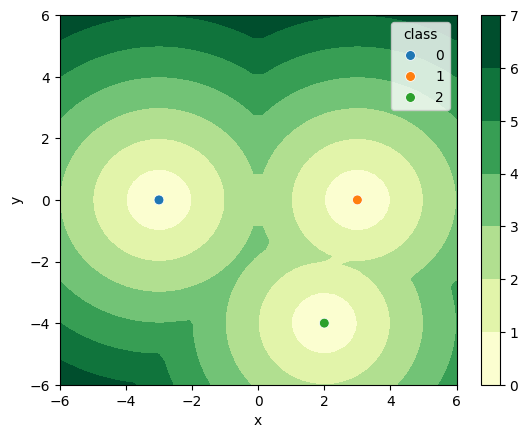

In [2]:
means = np.array([[-3, 0], [3, 0], [2, -4]])
class_labels = np.arange(means.shape[0])
size = 50
value_range = 6
x = np.linspace(-value_range, value_range, size)
y = np.linspace(-value_range, value_range, size)
grid_x, grid_y = np.meshgrid(x, y, indexing="ij")
grid_product = np.array(list(product(x, y)))

# compute distance to closest class
distance = [
    np.min(np.linalg.norm(grid_product[i, np.newaxis] - means, axis=1))
    for i in range(grid_product.shape[0])
]

z = np.reshape(distance, (size, size))
z_min, z_max = z.min(), z.max()

fig, ax = plt.subplots()
cmap = cm.YlGn  # cm.PuBu_r
cs = ax.contourf(grid_x, grid_y, z, cmap=cmap, vmin=z_min, vmax=z_max)
ax.axis([grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()])
cbar = fig.colorbar(cs)
data = pd.DataFrame(
    list(zip(means[:, 0], means[:, 1], class_labels)),
    columns=["x", "y", "class"],
)
sns.scatterplot(
    data=data,
    x="x",
    y="y",
    hue="class",
    s=50,
    palette="tab10",
    # alpha=0.5,
)
plt.show()

### Fit GP to estimate average epistemic uncertainty

In [3]:
import torch
import numpy as np
from omegaconf import OmegaConf
from gpytorch.mlls import ExactMarginalLogLikelihood
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
import gpytorch

/home/l.erlygin/miniconda/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
rng = np.random.default_rng(2)
train_size = 30
X = rng.random((train_size, 2)) * 6 - 3
Y = np.array(
    [
        np.min(np.linalg.norm(X[i, np.newaxis] - means, axis=1))
        for i in range(X.shape[0])
    ]
)
train_X = torch.tensor(X, dtype=torch.double)
train_Y = torch.tensor(Y[:, np.newaxis], dtype=torch.double)

In [5]:
gp = SingleTaskGP(
    train_X=train_X,
    train_Y=train_Y,
    input_transform=Normalize(d=2),
    outcome_transform=Standardize(m=1),
)
mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
fit_gpytorch_mll(mll);

In [6]:
product = torch.cartesian_prod(torch.tensor(x), torch.tensor(y))
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = gp.posterior(product)

In [7]:
lower, upper = observed_pred.confidence_region()

fig = go.Figure()
trace1 = go.Mesh3d(
    x=(product[:, 0]),
    y=(product[:, 1]),
    z=(observed_pred.mean.numpy()[:, 0]),
    opacity=0.5,
    color="rgba(244,22,100,0.6)",
)
fig.add_trace(trace1)

trace_lower = go.Mesh3d(
    x=(product[:, 0]),
    y=(product[:, 1]),
    z=(lower.numpy()),
    opacity=0.5,
    color="blue",
)
fig.add_trace(trace_lower)

trace_upper = go.Mesh3d(
    x=(product[:, 0]),
    y=(product[:, 1]),
    z=(upper.numpy()),
    opacity=0.5,
    color="blue",
)
fig.add_trace(trace_upper)
trace2 = go.Scatter3d(x=train_X[:, 0], y=train_X[:, 1], z=train_Y[:, 0], mode="markers")

fig.add_trace(trace2)

fig.update_layout(
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="Predicted distance"),
)
fig.show()

In [8]:
max_id = np.argmax(observed_pred.mean[:, 0]).item()
max_id, product[max_id]

(1241, tensor([-0.1224,  4.0408], dtype=torch.float64))

/tmp/ipykernel_1245079/2607090280.py:41: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



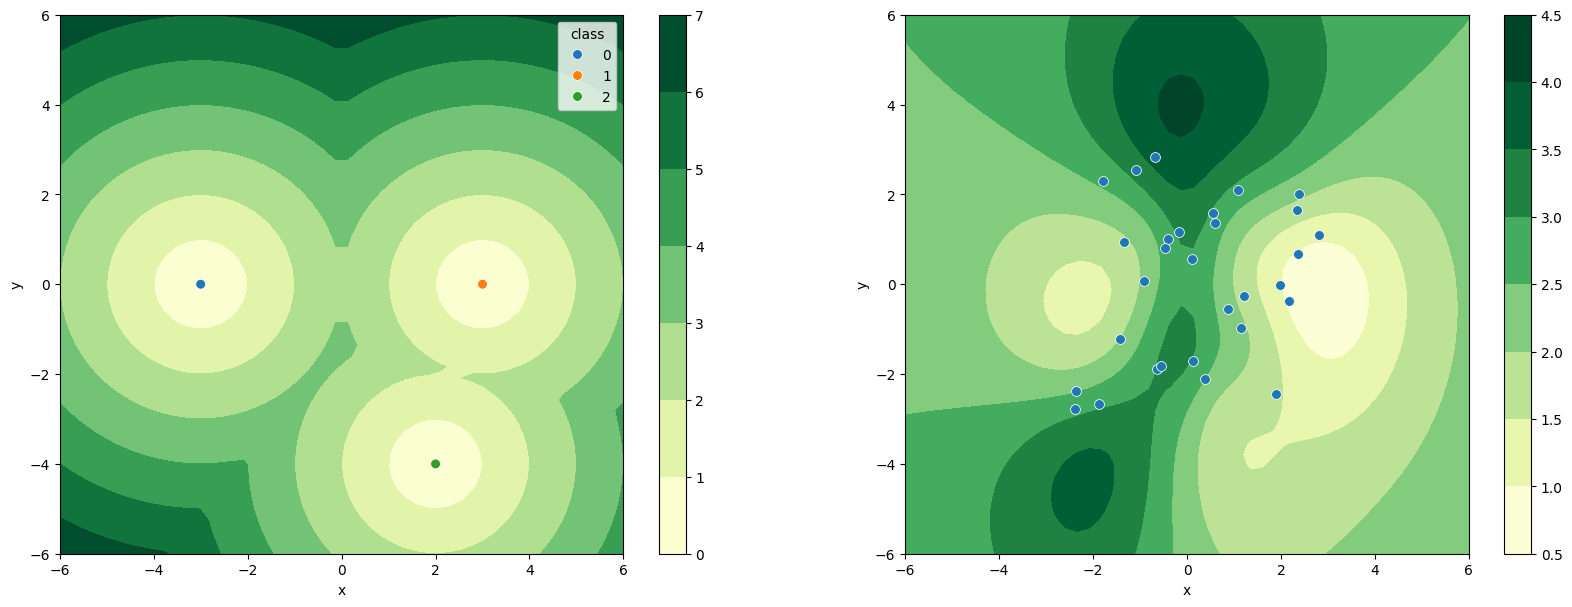

In [21]:
import matplotlib.pyplot as plt
import numpy as np


z = np.reshape(distance, (size, size))
z_min, z_max = z.min(), z.max()

fig, axes = plt.subplots(1, 2)
fig.set_figheight(7)
fig.set_figwidth(20)
cmap = cm.YlGn  # cm.PuBu_r
cs = axes[0].contourf(grid_x, grid_y, z, cmap=cmap, vmin=z_min, vmax=z_max)
# axes[0].axis([grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()])
cbar = fig.colorbar(cs)
data = pd.DataFrame(
    list(zip(means[:, 0], means[:, 1], class_labels)),
    columns=["x", "y", "class"],
)
sns.scatterplot(data=data, x="x", y="y", hue="class", s=50, palette="tab10", ax=axes[0])

z_gp = np.reshape(observed_pred.mean[:, 0].numpy(), (size, size))
z_min_gp, z_max_gp = z_gp.min(), z_gp.max()

cs = axes[1].contourf(grid_x, grid_y, z_gp, cmap=cmap, vmin=z_min_gp, vmax=z_max_gp)
axes[1].axis([x.min(), x.max(), y.min(), y.max()])
cbar = fig.colorbar(cs)


data_gp = pd.DataFrame(
    list(zip(X[:, 0], X[:, 1])),
    columns=["x", "y"],
)
sns.scatterplot(data=data_gp, x="x", y="y", s=50, palette="tab10", ax=axes[1])

# z_gp = np.reshape(observed_pred.std[:, 0].numpy(), (size, size))
# z_min_gp, z_max_gp = z_gp.min(), z_gp.max()

# cs = axes[2].contourf(grid_x, grid_y, z_gp, cmap=cmap, vmin=z_min_gp, vmax=z_max_gp)
# axes[2].axis([x.min(), x.max(), y.min(), y.max()])
# cbar = fig.colorbar(cs)

plt.show()

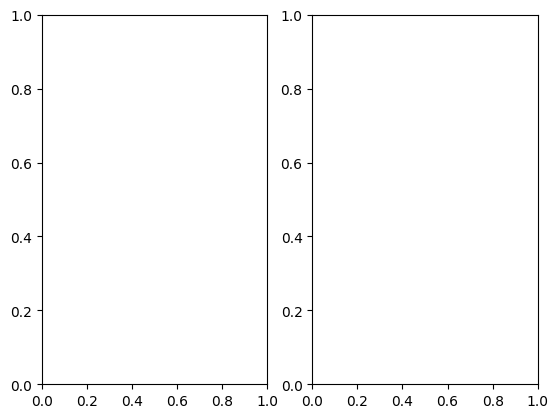

In [10]:
f, axes = plt.subplots(1, 2)